<a href="https://colab.research.google.com/github/sandro-silva/Data/blob/master/classificacao_multimodal_tumores_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação Multimodal de Lesões Dermoscópicas — ISIC 2020
## Alunos: Sandro e Ginaldo

**Disciplina:** Aprendizagem de Máquina

| Seção | Conteúdo |
|---|---|
| 1 | Setup, instalação e importações |
| 2 | Carregamento dos dados |
| 2b | EDA — 6 gráficos das peculiaridades |
| 3 | Pré-processamento tabular (idade, sexo, anatomia) |
| 4 | Divisão sem leakage — GroupKFold |
| 5 | Pré-processamento de imagens (7 etapas dermoscópicas) |
| 6 | Três arquiteturas multimodais |
| 7 | Focal Loss + loop de treino com tqdm |
| 8 | Treinamento — 2 épocas |
| 9 | Avaliação comparativa e visualizações |

## 1. Setup, Instalação e Importações

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# INSTALAÇÃO DAS DEPENDÊNCIAS
# Execute apenas uma vez por sessão Colab.
# tqdm: barra de progresso visual por época.
# ─────────────────────────────────────────────────────────────────────────────
!git clone https://github.com/sandro-silva/classificador_multimodal
!pip install -q tqdm

import torch
print(f'GPU disponível: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Cloning into 'classificador_multimodal'...
remote: Enumerating objects: 32697, done.
remote: Total 32697 (delta 0), reused 0 (delta 0), pack-reused 32697 (from 1)
Receiving objects: 100% (32697/32697), 163.38 MiB | 20.06 MiB/s, done.
Updating files: 100% (33127/33127), done.
GPU disponível: False


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTAÇÕES — organizadas por grupo temático
# ─────────────────────────────────────────────────────────────────────────────

# Dados e sistema de arquivos
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
sns.set_theme(style='whitegrid', palette='muted')

# Deep Learning — PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

# Pré-processamento e métricas — sklearn
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve, auc,
    f1_score, recall_score, precision_score
)
# Nota: accuracy_score NÃO importado como métrica principal.
# [P1] Com 98% de benignos, acurácia simples é enganosa — um modelo que
# chuta sempre benigno teria 98.2% sem detectar nenhum maligno.

# Progresso visual
from tqdm.notebook import tqdm
import time

# ── Reprodutibilidade ─────────────────────────────────────────────────────
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# Seleção automática do melhor hardware disponível
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Hardware selecionado: {device}')

Hardware selecionado: cpu


## 2. Carregamento dos Dados

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CARREGAMENTO DO DATASET ISIC 2020
# O repositório clonado contém:
#   data.csv  → 33.126 registros | 8 colunas | metadados clínicos
#   images/   → 33.126 arquivos ISIC_xxxxxxx.jpg
# ─────────────────────────────────────────────────────────────────────────────
ROOT = 'classificador_multimodal'
IMAGE_DIR = f'{ROOT}/images/'

df = pd.read_csv(f'{ROOT}/data.csv')

# Confirmação rápida das peculiaridades logo no carregamento
n_total   = len(df)
n_maligno = (df['target'] == 1).sum()
n_benigno = (df['target'] == 0).sum()
print(f'Total de amostras : {n_total:,}')
print(f'Benignos (0)       : {n_benigno:,}  ({n_benigno/n_total*100:.1f}%)')
print(f'Malignos (1)       : {n_maligno:,}   ({n_maligno/n_total*100:.2f}%)')
print(f'Razão              : {n_benigno/n_maligno:.1f}:1')  # [P1]
print(f'Pacientes únicos   : {df["patient_id"].nunique():,}')  # [P2]
print(f'\nNulos por coluna:\n{df.isnull().sum()[df.isnull().sum()>0]}')
df.head()

Total de amostras : 33,126
Benignos (0)       : 32,542  (98.2%)
Malignos (1)       : 584   (1.76%)
Razão              : 55.7:1
Pacientes únicos   : 2,056

Nulos por coluna:
sex                               65
age_approx                        68
anatom_site_general_challenge    527
dtype: int64


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


## 2b. Análise Exploratória (EDA) — As 5 Peculiaridades

| Peculiaridade | Impacto | Solução |
|---|---|---|
| **[P1]** Desbalanceamento 55:1 | Acurácia enganosa | Focal Loss + WeightedRandomSampler |
| **[P2]** 16 imagens/paciente | Data leakage | GroupKFold por patient_id |
| **[P3]** 82% diagnosis unknown | Feature inutilizável | Apenas sex, age, anatomy |
| **[P4]** NaN + age==0 anômalo | Features corrompidas | Imputação + StandardScaler |
| **[P5]** Imagens dermoscópicas | Artefatos e orientação livre | Augmentação específica |

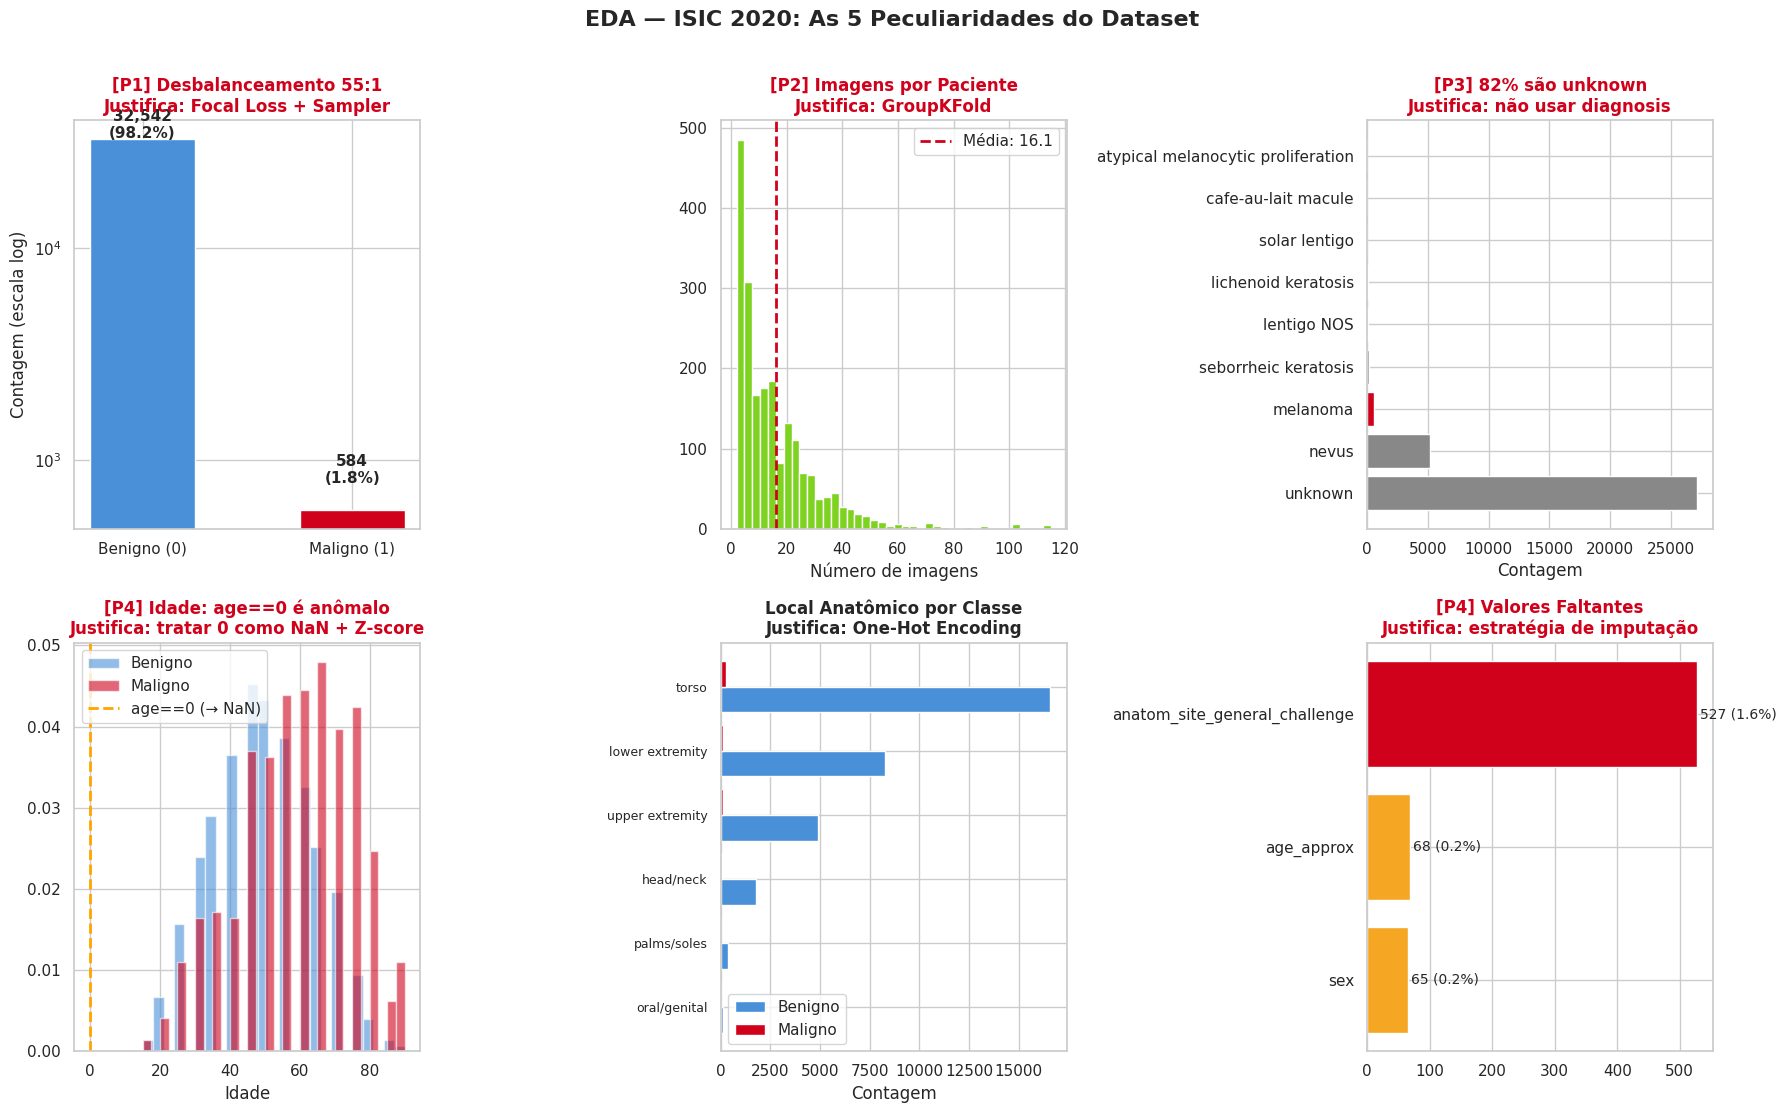

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA — 6 gráficos, cada um revelando uma peculiaridade do dataset
# ─────────────────────────────────────────────────────────────────────────────
fig, eixos = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('EDA — ISIC 2020: As 5 Peculiaridades do Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# [P1] Desbalanceamento severo
contagem = df['target'].value_counts().sort_index()
barras = eixos[0,0].bar(['Benigno (0)', 'Maligno (1)'], contagem.values,
                         color=['#4a90d9','#d0021b'], width=0.5)
for bar, v in zip(barras, contagem.values):
    eixos[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                    f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
eixos[0,0].set_yscale('log')
eixos[0,0].set_title('[P1] Desbalanceamento 55:1\nJustifica: Focal Loss + Sampler', fontsize=12, color='#d0021b', fontweight='bold')
eixos[0,0].set_ylabel('Contagem (escala log)')

# [P2] Imagens por paciente
imgs_pac = df.groupby('patient_id').size()
eixos[0,1].hist(imgs_pac.values, bins=40, color='#7ed321', edgecolor='white')
eixos[0,1].axvline(imgs_pac.mean(), color='#d0021b', linestyle='--', linewidth=2,
                    label=f'Média: {imgs_pac.mean():.1f}')
eixos[0,1].set_title('[P2] Imagens por Paciente\nJustifica: GroupKFold', fontsize=12, color='#d0021b', fontweight='bold')
eixos[0,1].set_xlabel('Número de imagens'); eixos[0,1].legend()

# [P3] Distribuição de diagnósticos
diag = df['diagnosis'].value_counts()
cores_d = ['#d0021b' if d=='melanoma' else '#888888' for d in diag.index]
eixos[0,2].barh(diag.index, diag.values, color=cores_d)
eixos[0,2].set_title('[P3] 82% são unknown\nJustifica: não usar diagnosis', fontsize=12, color='#d0021b', fontweight='bold')
eixos[0,2].set_xlabel('Contagem')

# [P4] Distribuição de idade por classe (incluindo age==0)
eixos[1,0].hist(df[df['target']==0]['age_approx'].dropna(),
                bins=30, alpha=0.6, color='#4a90d9', label='Benigno', density=True)
eixos[1,0].hist(df[df['target']==1]['age_approx'].dropna(),
                bins=30, alpha=0.6, color='#d0021b', label='Maligno', density=True)
eixos[1,0].axvline(0, color='orange', linestyle='--', linewidth=2, label='age==0 (→ NaN)')
eixos[1,0].set_title('[P4] Idade: age==0 é anômalo\nJustifica: tratar 0 como NaN + Z-score', fontsize=12, color='#d0021b', fontweight='bold')
eixos[1,0].set_xlabel('Idade'); eixos[1,0].legend()

# Feature útil: local anatômico por classe
locais = df.groupby(['anatom_site_general_challenge','target']).size().unstack(fill_value=0).sort_values(1)
x = range(len(locais))
eixos[1,1].barh([i-0.2 for i in x], locais[0].values, 0.4, color='#4a90d9', label='Benigno')
eixos[1,1].barh([i+0.2 for i in x], locais[1].values, 0.4, color='#d0021b', label='Maligno')
eixos[1,1].set_yticks(list(x)); eixos[1,1].set_yticklabels(locais.index, fontsize=9)
eixos[1,1].set_title('Local Anatômico por Classe\nJustifica: One-Hot Encoding', fontsize=12, fontweight='bold')
eixos[1,1].set_xlabel('Contagem'); eixos[1,1].legend()

# [P4] Valores faltantes
nulos = df.isnull().sum(); nulos = nulos[nulos>0].sort_values()
eixos[1,2].barh(nulos.index, nulos.values, color=['#f5a623' if v<100 else '#d0021b' for v in nulos.values])
for i, v in enumerate(nulos.values):
    eixos[1,2].text(v+5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=10)
eixos[1,2].set_title('[P4] Valores Faltantes\nJustifica: estratégia de imputação', fontsize=12, color='#d0021b', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_peculiaridades.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pré-processamento Tabular

Cada decisão abaixo é motivada por uma peculiaridade específica do dataset:

| Coluna | Problema | Solução |
|---|---|---|
| `age_approx` | age==0 impossível clinicamente; NaN; escala 0-90 | 0→NaN, fillna(mediana), **Z-score** |
| `sex` | 65 NaN; binário real | fillna(moda), map {male:0, female:1} |
| `anatom_site` | 527 NaN; categórico sem ordem | fillna('unknown'), **One-Hot** |

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.1 IDADE — [P4]
#
# Insight crítico: age==0 não representa recém-nascidos.
# O ISIC arredonda idades para múltiplos de 5 — o valor 0 é, na prática,
# ausência de dado. Tratamos como NaN antes de qualquer imputação.
#
# Por que Z-score (StandardScaler) e não min-max?
#   Min-max é sensível a outliers: um paciente de 90 anos estica toda a escala.
#   Z-score (x - média) / std é robusto a extremos e centraliza em torno de 0,
#   o que estabiliza o gradiente da camada Linear de entrada do MLP.
# ─────────────────────────────────────────────────────────────────────────────
df['age_approx'] = df['age_approx'].replace(0, np.nan)  # [P4] 0 → NaN
age_median = df['age_approx'].median()
df['age_approx'] = df['age_approx'].fillna(age_median)  # imputa mediana

scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age_approx']])

print(f'Mediana usada na imputação: {age_median}')
print(f'age_scaled — média: {df["age_scaled"].mean():.4f}  std: {df["age_scaled"].std():.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# 3.2 SEXO — [P4]
#
# Sexo é verdadeiramente binário: não há ordinalidade entre male e female.
# LabelEncoder criaria uma ordem artificial ({female:0, male:1, desconhecido:2})
# — a distância de 0→2 teria significado matemático sem base clínica.
# Mapeamento binário direto é semanticamente correto.
# NaN preenchido com a moda (o sexo mais frequente) — é mais informativo
# que 'desconhecido' para uma feature com significado biológico.
# ─────────────────────────────────────────────────────────────────────────────
moda_sexo = df['sex'].mode()[0]
df['sex'] = df['sex'].fillna(moda_sexo)           # [P4] fillna com moda
df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})  # binário real

print(f'\nModa usada para sex: {moda_sexo}')
print(f'sex_encoded — valores únicos: {sorted(df["sex_encoded"].unique())}')

# ─────────────────────────────────────────────────────────────────────────────
# 3.3 SÍTIO ANATÔMICO — [P4]
#
# O local anatômico tem 6 categorias reais sem ordem natural:
# torso, lower extremity, upper extremity, head/neck, palms/soles, oral/genital.
# LabelEncoder criaria: torso=5 > palms/soles=4 > ... sem sentido biológico.
# One-Hot Encoding cria colunas binárias independentes — sem ordinalidade falsa.
# NaN preenchido com 'unknown', que vira sua própria coluna binária.
# ─────────────────────────────────────────────────────────────────────────────
df['anatom_site_general_challenge'] = df['anatom_site_general_challenge'].fillna('unknown')

# pd.get_dummies gera automaticamente uma coluna por categoria
df = pd.get_dummies(df, columns=['anatom_site_general_challenge'],
                    prefix='anatom', dtype=float)

# Colunas geradas pelo One-Hot (variam conforme o dataset)
anatom_cols = [c for c in df.columns if c.startswith('anatom_')]
print(f'\nColunas One-Hot geradas ({len(anatom_cols)}): {anatom_cols}')

# ─────────────────────────────────────────────────────────────────────────────
# FEATURES TABULARES FINAIS — calculadas dinamicamente
# [P3] Diagnosis NÃO incluído: 82% são 'unknown', correlação 1:1 com target.
# Total: age_scaled(1) + sex_encoded(1) + anatom_*(7) = 9 features
# ─────────────────────────────────────────────────────────────────────────────
FEATURES_TABULARES = ['age_scaled', 'sex_encoded'] + anatom_cols
NUM_TABULAR_FEATURES = len(FEATURES_TABULARES)
print(f'\nTotal de features tabulares: {NUM_TABULAR_FEATURES}')
print(f'Features: {FEATURES_TABULARES}')

Mediana usada na imputação: 50.0
age_scaled — média: 0.0000  std: 1.0000

Moda usada para sex: male
sex_encoded — valores únicos: [np.int64(0), np.int64(1)]

Colunas One-Hot geradas (7): ['anatom_head/neck', 'anatom_lower extremity', 'anatom_oral/genital', 'anatom_palms/soles', 'anatom_torso', 'anatom_unknown', 'anatom_upper extremity']

Total de features tabulares: 9
Features: ['age_scaled', 'sex_encoded', 'anatom_head/neck', 'anatom_lower extremity', 'anatom_oral/genital', 'anatom_palms/soles', 'anatom_torso', 'anatom_unknown', 'anatom_upper extremity']


## 4. Divisão sem Leakage — GroupKFold

> **[P2]** O dataset tem 2.056 pacientes com **média de 16 imagens cada**.
> Uma divisão aleatória por imagem colocaria o mesmo paciente em treino E validação
> — o modelo "reconhece a pele" do paciente e a AUC é artificialmente inflada.

**GroupKFold** garante que todas as imagens de um paciente fiquem no mesmo fold.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [P2] GROUPKFOLD — divisão por paciente sem leakage
#
# GroupKFold(n_splits=5) cria 5 subconjuntos (folds) garantindo que
# cada patient_id apareça em APENAS UM fold.
#
# Estratégia: Fold 0 = Validação | Folds 1-4 = Treino
# Isso é equivalente a um 80/20 split, mas respeitando a estrutura de grupos.
# ─────────────────────────────────────────────────────────────────────────────
gkf = GroupKFold(n_splits=5)
df['fold'] = -1  # inicializa coluna

for fold, (train_idx, val_idx) in enumerate(
        gkf.split(df, df['target'], groups=df['patient_id'])):
    df.loc[val_idx, 'fold'] = fold

# Fold 0 = validação | Folds 1-4 = treino
train_df = df[df['fold'] != 0].reset_index(drop=True)
val_df   = df[df['fold'] == 0].reset_index(drop=True)

print(f'Treino:    {len(train_df):,} imagens | {train_df["target"].sum()} malignos ({train_df["target"].mean()*100:.2f}%)')
print(f'Validação: {len(val_df):,} imagens | {val_df["target"].sum()} malignos ({val_df["target"].mean()*100:.2f}%)')

# ── SANITY CHECK: zero vazamento ─────────────────────────────────────────
# Verifica explicitamente que nenhum patient_id aparece nos dois conjuntos
train_pacs = set(train_df['patient_id'].unique())
val_pacs   = set(val_df['patient_id'].unique())
vazamento  = train_pacs.intersection(val_pacs)

if len(vazamento) == 0:
    print('\n[P2] SUCESSO: Zero vazamento de pacientes entre treino e validação!')
else:
    print(f'\n[P2] ERRO FATAL: {len(vazamento)} pacientes em ambos os conjuntos!')

# Salva os DataFrames processados para uso nas fases seguintes
train_df.to_csv('train_processed.csv', index=False)
val_df.to_csv('val_processed.csv', index=False)
print('DataFrames processados salvos: train_processed.csv | val_processed.csv')

Treino:    26,501 imagens | 476 malignos (1.80%)
Validação: 6,625 imagens | 108 malignos (1.63%)

[P2] SUCESSO: Zero vazamento de pacientes entre treino e validação!
DataFrames processados salvos: train_processed.csv | val_processed.csv


## 5. Pré-processamento de Imagens e DataLoaders

**[P5]** Imagens dermoscópicas exigem augmentação específica:

| Etapa | Técnica | Por que para dermoscopia |
|---|---|---|
| 1 | `RandomResizedCrop` | Simula distâncias variadas do dermatoscópio |
| 2-3 | `Flip H + V` | Lesões sem orientação preferencial |
| 4 | `RandomRotation(180°)` | Captura em qualquer ângulo |
| 5 | `ColorJitter` com hue | Variação de iluminação e pigmentação |
| 6 | `Normalize` ImageNet | Obrigatório para backbones pré-treinados |
| 7 | `RandomErasing` | Evita dependência de artefatos locais |

**[P1]** `WeightedRandomSampler` garante ~50% de malignos por lote.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# RECARREGAR DADOS PROCESSADOS
# Carrega os CSVs salvos na fase anterior
# ─────────────────────────────────────────────────────────────────────────────
train_df = pd.read_csv('train_processed.csv')
val_df   = pd.read_csv('val_processed.csv')

# Recria a lista de features tabulares dinamicamente (para quando a sessão reinicia)
FEATURES_TABULARES = (['age_scaled', 'sex_encoded'] +
                      [c for c in train_df.columns if c.startswith('anatom_')])
NUM_TABULAR_FEATURES = len(FEATURES_TABULARES)
print(f'Features tabulares ativas ({NUM_TABULAR_FEATURES}): {FEATURES_TABULARES}')

Features tabulares ativas (9): ['age_scaled', 'sex_encoded', 'anatom_head/neck', 'anatom_lower extremity', 'anatom_oral/genital', 'anatom_palms/soles', 'anatom_torso', 'anatom_unknown', 'anatom_upper extremity']


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [P5] PIPELINES DE AUGMENTAÇÃO
# Dois pipelines obrigatórios:
#   treino → augmentação aleatória (multiplica artificialmente os ~470 malignos)
#   val    → determinístico (resultados comparáveis entre execuções)
# ─────────────────────────────────────────────────────────────────────────────
IMAGE_SIZE = 224

train_transforms = transforms.Compose([
    # [P5] Simula distância variável do dermatoscópio
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    # [P5] Lesões sem orientação preferencial
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    # [P5] Captura em qualquer ângulo — 180° cobre espaço real de orientações
    transforms.RandomRotation(degrees=180),
    # [P5] Variação de iluminação e pigmentação entre equipamentos e pacientes
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    # Normalização ImageNet — OBRIGATÓRIA para backbones pré-treinados
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # [P5][P1] Força aprendizado distribuído — evita artefatos memorizados nos ~470 malignos
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0),
])

val_transforms = transforms.Compose([
    # Sem augmentação — avaliação determinística e comparável
    transforms.Resize(int(IMAGE_SIZE * 1.1)),  # resize levemente maior
    transforms.CenterCrop(IMAGE_SIZE),          # crop central preserva a lesão
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print(f'Pipeline treino:    {len(train_transforms.transforms)} etapas')
print(f'Pipeline validação: {len(val_transforms.transforms)} etapas')

Pipeline treino:    8 etapas
Pipeline validação: 4 etapas


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASET MULTIMODAL
# Cada amostra retorna: imagem (tensor [3,224,224]) + tabulares (tensor [9]) + alvo
# [P3] Features tabulares excluem 'diagnosis' (82% unknown = leakage)
# ─────────────────────────────────────────────────────────────────────────────
class ISICMultimodalDataset(Dataset):
    def __init__(self, dataframe, image_dir, tabular_features, transform=None):
        self.df               = dataframe.reset_index(drop=True)
        self.image_dir        = image_dir
        self.tabular_features = tabular_features
        self.transform        = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Carrega imagem com fallback .png para robustez
        img_name = row['image_name']
        img_path = os.path.join(self.image_dir, f'{img_name}.jpg')
        if not os.path.exists(img_path):
            img_path = os.path.join(self.image_dir, f'{img_name}.png')
        # .convert('RGB') garante 3 canais — algumas ISIC são RGBA ou grayscale
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # [P3][P4] Features tabulares: todas em escala comparável
        tabular = torch.tensor(
            row[self.tabular_features].values.astype(np.float32),
            dtype=torch.float32
        )
        # float32 obrigatório para compatibilidade com BCEWithLogitsLoss / FocalLoss
        target = torch.tensor(row['target'], dtype=torch.float32)
        return image, tabular, target

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [P1] WEIGHTEDRANDSAMPLER — oversampling por lote
#
# Sem sampler: lote de 32 tem ~0.6 malignos em média (55:1).
# Com sampler: lote de 32 tem ~16 malignos — balanceamento 1:1.
# peso_maligno = 1/n_malignos >> peso_benigno = 1/n_benignos
# replacement=True: malignos são repetidos com augmentação variada.
# ─────────────────────────────────────────────────────────────────────────────
n_neg = (train_df['target'] == 0).sum()
n_pos = (train_df['target'] == 1).sum()
class_weights   = [1.0/n_neg, 1.0/n_pos]
sample_weights  = [class_weights[int(t)] for t in train_df['target'].values]

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# ── Cálculo do pos_weight para Focal Loss ─────────────────────────────────
# pos_weight = n_negativos / n_positivos ≈ 55
# Amplifica o erro nos malignos dentro da loss [P1]
PESO_POSITIVO = torch.tensor([n_neg / n_pos], dtype=torch.float32)

BATCH_SIZE = 32

train_dataset = ISICMultimodalDataset(train_df, IMAGE_DIR, FEATURES_TABULARES, train_transforms)
val_dataset   = ISICMultimodalDataset(val_df,   IMAGE_DIR, FEATURES_TABULARES, val_transforms)

# sampler e shuffle são mutuamente exclusivos no PyTorch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

print(f'Treino:    {len(train_dataset):,} imagens | {len(train_loader)} batches')
print(f'Validação: {len(val_dataset):,} imagens | {len(val_loader)} batches')
print(f'pos_weight (Focal Loss): {PESO_POSITIVO.item():.2f}')

# Sanity check: confirma balanceamento no primeiro lote
imgs_b, tab_b, tgt_b = next(iter(train_loader))
n_mal = int(tgt_b.sum().item())
print(f'\nSanity check — primeiro lote: {BATCH_SIZE - n_mal} benignos | {n_mal} malignos')
print(f'Tensores: imgs={imgs_b.shape} | tab={tab_b.shape} | target={tgt_b.shape}')
if n_mal > BATCH_SIZE * 0.1:
    print('[P1] SUCESSO: Sampler está forçando malignos nos lotes!')

Treino:    26,501 imagens | 829 batches
Validação: 6,625 imagens | 208 batches
pos_weight (Focal Loss): 54.67

Sanity check — primeiro lote: 16 benignos | 16 malignos
Tensores: imgs=torch.Size([32, 3, 224, 224]) | tab=torch.Size([32, 9]) | target=torch.Size([32])
[P1] SUCESSO: Sampler está forçando malignos nos lotes!


## 6. Três Arquiteturas Multimodais

Cada arquitetura representa uma estratégia diferente de fusão de modalidades:

| # | Arquitetura | Backbone | Fusão | dim visual | Parâmetros |
|---|---|---|---|---|---|
| 1 | **LateFusionBaseline** | MobileNetV2 | Concatenação simples | 1280 | ~3.6M |
| 2 | **ResNetMultimodal** | ResNet18 | Concatenação + BatchNorm | 512 | ~11.2M |
| 3 | **GatedMultimodalNetwork** | MobileNetV3-Small | **Atenção cruzada (gate)** | 576→256 | ~2.6M |

**[P1]** Transfer Learning com ImageNet compensa os ~470 malignos do treino.
**[P3]** Ramo tabular recebe as 9 features clínicas (sem diagnosis).

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODELO 1: LateFusionBaseline
#
# Estratégia: Late Fusion por concatenação direta.
# Backbone: MobileNetV2 — leve (3.4M params), 1280 dims após GlobalAvgPool.
# [P1] Com ~470 malignos, modelos menores overfitam menos.
# Fluxo: imagem → CNN → 1280 | tabular → MLP → 64 | cat → 1344 → 128 → 1
# ─────────────────────────────────────────────────────────────────────────────
class LateFusionBaseline(nn.Module):
    def __init__(self, num_tabular_features):
        super().__init__()

        # Ramo Visual — MobileNetV2 pré-treinado (ImageNet)
        self.image_extrator = models.mobilenet_v2(pretrained=True)
        # Substituímos o classifier por Identity: saída = [B, 1280]
        self.image_extrator.classifier = nn.Identity()

        # [P3] Ramo Tabular — 9 features clínicas → 64
        # Dropout(0.3): poucas features → risco de co-adaptação [P1]
        self.tabular_extrator = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Fusão: 1280 (visual) + 64 (tabular) = 1344
        self.classifier = nn.Sequential(
            nn.Linear(1280 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)  # logit — sigmoid aplicado na inferência
        )

    def forward(self, image, tabular):
        img_feat = self.image_extrator(image)          # [B, 1280]
        tab_feat = self.tabular_extrator(tabular)      # [B, 64]
        combined = torch.cat((img_feat, tab_feat), 1)  # [B, 1344]
        return self.classifier(combined).squeeze(1)    # [B] logit

In [ ]:
# MODELO 2: ResNetMultimodal
#
# Estratégia: Late Fusion com BatchNorm no ramo tabular e no classificador.
# Backbone: ResNet18 — residual clássico, 512 dims, 2.3× mais rápido que ResNet50.
# Skip connections evitam vanishing gradient com dataset pequeno [P1].
# BatchNorm normaliza as ativações internas — estabiliza o treino.
# Fluxo: imagem → CNN → 512 | tabular → BN MLP → 64 | cat → 576 → BN → 256 → 1
# ─────────────────────────────────────────────────────────────────────────────
class ResNetMultimodal(nn.Module):
    def __init__(self, num_tabular_features):
        super().__init__()

        # Ramo Visual — ResNet18 pré-treinado# ─────────────────────────────────────────────────────────────────────────────

        self.image_extrator = models.resnet18(pretrained=True)
        # Substituímos o FC final: saída = [B, 512]
        self.image_extrator.fc = nn.Identity()

        # [P3] Ramo Tabular com BatchNorm — estabiliza features de escalas diferentes [P4]
        # Z-score já normalizou age, mas One-Hot cria binários {0,1} — BN ajusta tudo
        self.tabular_extrator = nn.Sequential(
            nn.Linear(num_tabular_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Fusão: 512 + 64 = 576 → classificador com BatchNorm
        self.classifier = nn.Sequential(
            nn.Linear(512 + 64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

    def forward(self, image, tabular):
        img_feat = self.image_extrator(image)          # [B, 512]
        tab_feat = self.tabular_extrator(tabular)      # [B, 64]
        combined = torch.cat((img_feat, tab_feat), 1)  # [B, 576]
        return self.classifier(combined).squeeze(1)    # [B] logit

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODELO 3: GatedMultimodalNetwork
#
# Estratégia: Fusão com MECANISMO DE ATENÇÃO (Gate).
# Backbone: MobileNetV3-Small — o mais leve dos 3 (2.5M params, 576 dims).
#
# Como funciona o Gate?
#   1. Projeta imagem (576) e tabular (N) para o mesmo espaço latente (256)
#   2. Calcula um vetor gate ∈ [0,1] via Sigmoid(Linear(visual||tabular))
#   3. Fusão: fused = gate × visual + (1-gate) × tabular
#
# Interpretação: o gate aprende DINAMICAMENTE o quanto confiar em cada
# modalidade por amostra. Para lesões com imagem ambígua, o gate aumenta
# o peso dos metadados clínicos — e vice-versa.
# [P1] Isso é especialmente útil com ~470 malignos: o gate pode compensar
# imagens de difícil classificação visual com os dados clínicos.
# ─────────────────────────────────────────────────────────────────────────────
class GatedMultimodalNetwork(nn.Module):
    def __init__(self, num_tabular_features, embed_dim=256):
        super().__init__()

        # Ramo Visual — MobileNetV3-Small pré-treinado
        self.image_extrator = models.mobilenet_v3_small(pretrained=True)
        # Saída após avgpool + flatten: [B, 576]
        self.image_extrator.classifier = nn.Identity()
        # Projeta 576 → embed_dim (256)
        self.visual_proj = nn.Linear(576, embed_dim)

        # [P3] Ramo Tabular — projeta para o mesmo espaço latente (256)
        self.tabular_proj = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim)
        )

        # Gate: aprende o peso relativo de cada modalidade
        # Entrada: visual(256) || tabular(256) = 512 dims
        # Saída: vetor de 256 pesos ∈ [0,1]
        self.gate = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.Sigmoid()  # [0,1] — interpretável como proporção de atenção
        )

        # Classificador final sobre o vetor fundido (256 dims)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, image, tabular):
        # 1. Extração
        img_raw = self.image_extrator(image)    # [B, 576]
        tab_raw = self.tabular_proj(tabular)    # [B, 256]

        # 2. Projeção para espaço comum
        v = torch.relu(self.visual_proj(img_raw))  # [B, 256]
        t = torch.relu(tab_raw)                    # [B, 256]

        # 3. Cálculo do Gate — atenção dinâmica por amostra
        gate_w = self.gate(torch.cat((v, t), dim=1))  # [B, 256] ∈ [0,1]

        # 4. Fusão ponderada: gate controla imagem; (1-gate) controla tabular
        fused = gate_w * v + (1 - gate_w) * t          # [B, 256]

        return self.classifier(fused).squeeze(1)        # [B] logit

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SANITY CHECK DAS ARQUITETURAS
# Passa um lote pelos 3 modelos antes do treino para garantir que os shapes
# de tensor fluem sem erros de dimensão.
# ─────────────────────────────────────────────────────────────────────────────
modelo1 = LateFusionBaseline(NUM_TABULAR_FEATURES)
modelo2 = ResNetMultimodal(NUM_TABULAR_FEATURES)
modelo3 = GatedMultimodalNetwork(NUM_TABULAR_FEATURES)

imgs_b, tab_b, tgt_b = next(iter(train_loader))
print(f'Entrada — imagem: {imgs_b.shape} | tabular: {tab_b.shape} | target: {tgt_b.shape}')
print('-' * 55)

with torch.no_grad():
    out1 = modelo1(imgs_b, tab_b)
    out2 = modelo2(imgs_b, tab_b)
    out3 = modelo3(imgs_b, tab_b)

print(f'Saída Modelo 1 (LateFusion):  shape={out1.shape} → OK')
print(f'Saída Modelo 2 (ResNet18):    shape={out2.shape} → OK')
print(f'Saída Modelo 3 (GatedAttn):   shape={out3.shape} → OK')

# Resumo de parâmetros treináveis
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print('\nParâmetros treináveis:')
for nome, m in [('LateFusionBaseline', modelo1),('ResNetMultimodal', modelo2),('GatedMultimodal', modelo3)]:
    print(f'  {nome:<22} {count_params(m):>10,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 156MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 157MB/s]


Entrada — imagem: torch.Size([32, 3, 224, 224]) | tabular: torch.Size([32, 9]) | target: torch.Size([32])
-------------------------------------------------------
Saída Modelo 1 (LateFusion):  shape=torch.Size([32]) → OK
Saída Modelo 2 (ResNet18):    shape=torch.Size([32]) → OK
Saída Modelo 3 (GatedAttn):   shape=torch.Size([32]) → OK

Parâmetros treináveis:
  LateFusionBaseline      2,396,801
  ResNetMultimodal       11,334,785
  GatedMultimodal         1,239,841


## 7. Focal Loss e Loop de Treinamento

> **[P1]** `BCEWithLogitsLoss` padrão com 55:1 de desbalanceamento faz o modelo
> aprender a chutar sempre benigno. A **Focal Loss** suprime amostras fáceis
> e força atenção nos malignos difíceis: `FL = -α(1-pt)^γ · log(pt)`

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [P1] FOCAL LOSS — solução para o desbalanceamento 55:1
#
# Ref: Lin et al. 2017 (RetinaNet)
# FL(pt) = -alpha × (1 - pt)^gamma × log(pt)
#
# pt = probabilidade correta:
#   Benigno fácil (pt=0.95): (1-0.95)^2 = 0.0025 → contribuição mínima
#   Maligno difícil (pt=0.30): (1-0.30)^2 = 0.49 → contribuição grande
#
# Combinação com pos_weight: dupla compensação do desbalanceamento.
#   pos_weight ≈ 55 amplifica o erro dos malignos
#   (1-pt)^gamma suprime os benignos fáceis
# ─────────────────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha      = alpha
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        # BCE com pos_weight como base — numericamente estável (sigmoid interno)
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=self.pos_weight.to(logits.device) if self.pos_weight is not None else None,
            reduction='none'  # por-amostra para aplicar o fator focal
        )
        pt           = torch.exp(-bce)                     # probabilidade correta
        focal_weight = self.alpha * (1.0 - pt) ** self.gamma
        return (focal_weight * bce).mean()

criterion = FocalLoss(alpha=0.25, gamma=2.0, pos_weight=PESO_POSITIVO)
print(f'[P1] Focal Loss: alpha=0.25 | gamma=2.0 | pos_weight={PESO_POSITIVO.item():.2f}')

[P1] Focal Loss: alpha=0.25 | gamma=2.0 | pos_weight=54.67


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LOOP DE TREINAMENTO — integra todas as soluções para as peculiaridades
#
#   [P1] Focal Loss + WeightedRandomSampler: combate o desbalanceamento
#   [P2] loader_val com pacientes exclusivos (GroupKFold garantiu isso)
#   [P1] Monitora Sensibilidade e AUC-ROC — NÃO acurácia simples
#   tqdm: barra de progresso visual por época
# ─────────────────────────────────────────────────────────────────────────────
def treinar_e_avaliar(model, num_epochs, train_loader, val_loader,
                      criterion, optimizer, device, nome_modelo='Modelo'):
    model = model.to(device)
    historico = {
        'train_loss': [], 'val_loss': [],
        'val_auc':    [], 'val_f1':  [],
        'val_recall': []  # recall = sensibilidade = TP/(TP+FN)
    }

    for epoch in range(num_epochs):
        inicio = time.time()

        # ── TREINO ──────────────────────────────────────────────────────────
        # [P1] Cada lote recebe ~50% malignos (WeightedRandomSampler)
        model.train()
        total_loss = 0.0
        loop = tqdm(train_loader,
                    desc=f'[{nome_modelo}] Ép {epoch+1}/{num_epochs} Treino',
                    leave=False)

        for images, tabulars, targets in loop:
            images, tabulars, targets = (
                images.to(device), tabulars.to(device), targets.to(device)
            )
            optimizer.zero_grad()
            outputs = model(images, tabulars)         # [B] logits
            loss    = criterion(outputs, targets)     # [P1] Focal Loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            loop.set_postfix(loss=f'{loss.item():.4f}')

        epoch_train_loss = total_loss / len(train_loader.dataset)

        # ── VALIDAÇÃO ───────────────────────────────────────────────────────
        # [P2] val_loader contém apenas pacientes EXCLUSIVOS do treino
        model.eval()
        val_loss_total = 0.0
        all_targets, all_probs, all_preds = [], [], []

        with torch.no_grad():
            for images, tabulars, targets in val_loader:
                images, tabulars, targets = (
                    images.to(device), tabulars.to(device), targets.to(device)
                )
                outputs = model(images, tabulars)
                val_loss_total += criterion(outputs, targets).item() * images.size(0)
                probs = torch.sigmoid(outputs)
                preds = (probs >= 0.5).float()
                all_targets.extend(targets.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

        epoch_val_loss = val_loss_total / len(val_loader.dataset)

        # [P1] Métricas: AUC-ROC e Sensibilidade (não acurácia simples)
        try:
            val_auc = roc_auc_score(all_targets, all_probs)
        except ValueError:
            val_auc = 0.0

        val_f1     = f1_score(all_targets, all_preds, zero_division=0)
        val_recall = recall_score(all_targets, all_preds, zero_division=0)

        historico['train_loss'].append(epoch_train_loss)
        historico['val_loss'].append(epoch_val_loss)
        historico['val_auc'].append(val_auc)
        historico['val_f1'].append(val_f1)
        historico['val_recall'].append(val_recall)

        elapsed = time.time() - inicio
        print(f'[{nome_modelo}] Ép {epoch+1}/{num_epochs} [{elapsed:.0f}s] | '
              f'Loss T:{epoch_train_loss:.4f} V:{epoch_val_loss:.4f} | '
              f'AUC-ROC:{val_auc:.4f} | F1:{val_f1:.4f} | '
              f'Sensib:{val_recall:.4f}')  # [P1] sensibilidade = % malignos detectados

    return model, historico

## 8. Treinamento — 2 Épocas

Com `WeightedRandomSampler` ativo, cada época já é muito mais informativa
que sem sampler. **Tempo estimado no Colab T4:**

| Modelo | Tempo/época | 2 épocas |
|---|---|---|
| LateFusionBaseline | ~6 min | ~12 min |
| ResNetMultimodal | ~8 min | ~16 min |
| GatedMultimodal | ~4 min | ~8 min |
| **Total** | | **~36 min** |

In [ ]:
NUM_EPOCHS = 2  # rápido para Colab gratuito — aumente para 10+ em produção

# ─────────────────────────────────────────────────────────────────────────────
# MODELO 1 — LateFusionBaseline (MobileNetV2)
# AdamW: melhor que Adam com augmentação pesada (weight_decay regulariza)
# lr=1e-4: conservador para não destruir pesos pré-treinados [P1]
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('TREINO 1/3 — LateFusionBaseline (MobileNetV2)')
print('=' * 60)
modelo1 = LateFusionBaseline(NUM_TABULAR_FEATURES)
optim1  = optim.AdamW(modelo1.parameters(), lr=1e-4, weight_decay=1e-2)
modelo1, hist1 = treinar_e_avaliar(
    modelo1, NUM_EPOCHS, train_loader, val_loader,
    criterion, optim1, device, 'LateFusion'
)
torch.save(modelo1.state_dict(), 'modelo_latefusion.pth')
print('Modelo 1 salvo!')

# ─────────────────────────────────────────────────────────────────────────────
# MODELO 2 — ResNetMultimodal (ResNet18)
# ResNet18: 2.3× mais rápido que ResNet50, skip connections estabilizam [P1]
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('TREINO 2/3 — ResNetMultimodal (ResNet18)')
print('=' * 60)
modelo2 = ResNetMultimodal(NUM_TABULAR_FEATURES)
optim2  = optim.AdamW(modelo2.parameters(), lr=1e-4, weight_decay=1e-2)
modelo2, hist2 = treinar_e_avaliar(
    modelo2, NUM_EPOCHS, train_loader, val_loader,
    criterion, optim2, device, 'ResNet18'
)
torch.save(modelo2.state_dict(), 'modelo_resnet.pth')
print('Modelo 2 salvo!')

# ─────────────────────────────────────────────────────────────────────────────
# MODELO 3 — GatedMultimodalNetwork (MobileNetV3-Small)
# O mais leve dos 3; Gate aprende dinamicamente a ponderar imagem vs tabular
# [P1] Útil quando a imagem é ambígua — o gate aumenta o peso dos metadados
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('TREINO 3/3 — GatedMultimodalNetwork (MobileNetV3-Small)')
print('=' * 60)
modelo3 = GatedMultimodalNetwork(NUM_TABULAR_FEATURES)
optim3  = optim.AdamW(modelo3.parameters(), lr=1e-4, weight_decay=1e-2)
modelo3, hist3 = treinar_e_avaliar(
    modelo3, NUM_EPOCHS, train_loader, val_loader,
    criterion, optim3, device, 'GatedAttn'
)
torch.save(modelo3.state_dict(), 'modelo_gated.pth')
print('Modelo 3 salvo!')

TREINO 1/3 — LateFusionBaseline (MobileNetV2)


[LateFusion] Ép 1/2 Treino:   0%|          | 0/829 [00:00<?, ?it/s]

[LateFusion] Ép 1/2 [4638s] | Loss T:0.3876 V:0.4483 | AUC-ROC:0.8633 | F1:0.0495 | Sensib:0.9907


[LateFusion] Ép 2/2 Treino:   0%|          | 0/829 [00:00<?, ?it/s]

[LateFusion] Ép 2/2 [4704s] | Loss T:0.2979 V:0.4926 | AUC-ROC:0.8726 | F1:0.0542 | Sensib:0.9907
Modelo 1 salvo!

TREINO 2/3 — ResNetMultimodal (ResNet18)


...

[ResNet18] Ép 2/2 [7590s] | Loss T:0.3822 V:0.3890 | AUC-ROC:0.8649 | F1:0.0496 | Sensib:1.0000
Modelo 2 salvo!

TREINO 3/3 — GatedMultimodalNetwork (MobileNetV3-Small)


[GatedAttn] Ép 1/2 Treino:   0%|          | 0/829 [00:00<?, ?it/s]

[GatedAttn] Ép 1/2 [1343s] | Loss T:0.5097 V:0.5061 | AUC-ROC:0.8594 | F1:0.0326 | Sensib:1.0000


[GatedAttn] Ép 2/2 Treino:   0%|          | 0/829 [00:00<?, ?it/s]

[GatedAttn] Ép 2/2 [1339s] | Loss T:0.3094 V:0.3809 | AUC-ROC:0.8700 | F1:0.0544 | Sensib:0.9907
Modelo 3 salvo!


## 9. Avaliação Comparativa e Visualizações

> **[P1]** As métricas foram escolhidas especificamente pelo desbalanceamento 55:1.
> Acurácia simples **não aparece** como critério principal — um modelo que chuta
> sempre benigno teria 98.2% e **zero** sensibilidade.

| Métrica | Por que importa neste dataset |
|---|---|
| **Sensibilidade (Recall)** | % malignos detectados — melanoma não detectado = risco de vida |
| **AUC-ROC** | Discriminação geral em todos os limiares |
| **F1-Score** | Balanço precisão/sensibilidade |
| **Especificidade** | % benignos corretos — evita biópsias desnecessárias |

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CARREGAMENTO DOS MODELOS PARA INFERÊNCIA
# Carrega os pesos salvos e coloca em modo eval
# ─────────────────────────────────────────────────────────────────────────────
modelo1_final = LateFusionBaseline(NUM_TABULAR_FEATURES).to(device)
modelo1_final.load_state_dict(torch.load('modelo_latefusion.pth', map_location=device))
modelo1_final.eval()

modelo2_final = ResNetMultimodal(NUM_TABULAR_FEATURES).to(device)
modelo2_final.load_state_dict(torch.load('modelo_resnet.pth', map_location=device))
modelo2_final.eval()

modelo3_final = GatedMultimodalNetwork(NUM_TABULAR_FEATURES).to(device)
modelo3_final.load_state_dict(torch.load('modelo_gated.pth', map_location=device))
modelo3_final.eval()

print('3 modelos carregados para inferência.')

3 modelos carregados para inferência.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EXTRAÇÃO DE PREDIÇÕES
# [P2] val_loader contém apenas pacientes EXCLUSIVOS do treino (GroupKFold)
# ─────────────────────────────────────────────────────────────────────────────
def get_predictions(model, loader, device):
    model.eval()
    all_targets, all_probs = [], []
    with torch.no_grad():
        for images, tabulars, targets in loader:
            images, tabulars = images.to(device), tabulars.to(device)
            outputs = model(images, tabulars)
            probs   = torch.sigmoid(outputs).cpu().numpy()
            all_targets.extend(targets.numpy())
            all_probs.extend(probs)
    return np.array(all_targets), np.array(all_probs)

print('Extraindo probabilidades...')
y_true,  probs1 = get_predictions(modelo1_final, val_loader, device)
_, probs2       = get_predictions(modelo2_final, val_loader, device)
_, probs3       = get_predictions(modelo3_final, val_loader, device)

# Limiar 0.5 para predições binárias
preds1 = (probs1 >= 0.5).astype(int)
preds2 = (probs2 >= 0.5).astype(int)
preds3 = (probs3 >= 0.5).astype(int)

print('Inferência concluída!')

Extraindo probabilidades...
Inferência concluída!


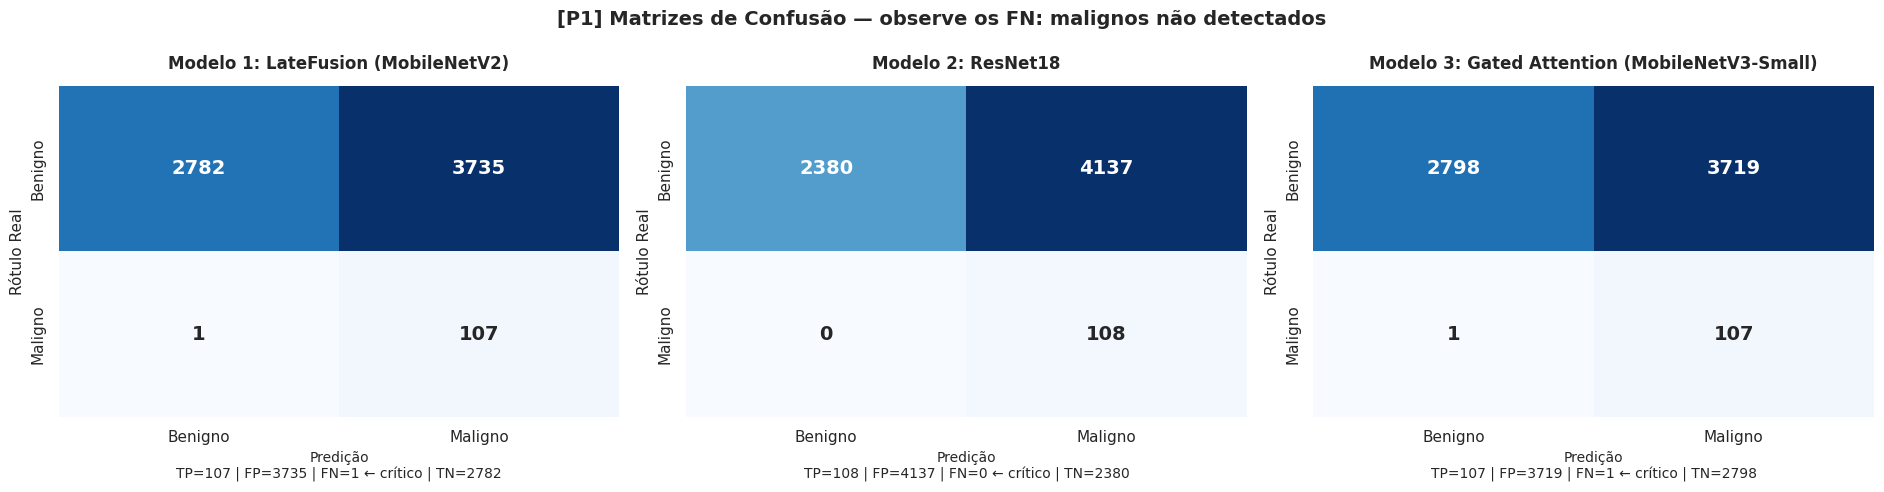


Foco: quadrante inferior direito (TP) deve ser maximizado.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [P1] MATRIZES DE CONFUSÃO — foco no FN (malignos não detectados)
#
# FN (Maligno → Benigno): ERRO CRÍTICO — melanoma não tratado
# TP (Maligno → Maligno): objetivo — queremos maximizar
# TN (Benigno → Benigno): acerto abundante da maioria
# FP (Benigno → Maligno): falso alarme — biópsia desnecessária
# ─────────────────────────────────────────────────────────────────────────────
titulos   = ['Modelo 1: LateFusion (MobileNetV2)',
             'Modelo 2: ResNet18',
             'Modelo 3: Gated Attention (MobileNetV3-Small)']
predicoes = [preds1, preds2, preds3]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for i, ax in enumerate(axes):
    cm = confusion_matrix(y_true, predicoes[i])
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'},
                xticklabels=['Benigno', 'Maligno'],
                yticklabels=['Benigno', 'Maligno'])
    ax.set_title(titulos[i], fontsize=12, pad=12, fontweight='bold')
    ax.set_xlabel(f'Predição\nTP={tp} | FP={fp} | FN={fn} ← crítico | TN={tn}', fontsize=10)
    ax.set_ylabel('Rótulo Real', fontsize=11)

fig.suptitle('[P1] Matrizes de Confusão — observe os FN: malignos não detectados',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nFoco: quadrante inferior direito (TP) deve ser maximizado.')

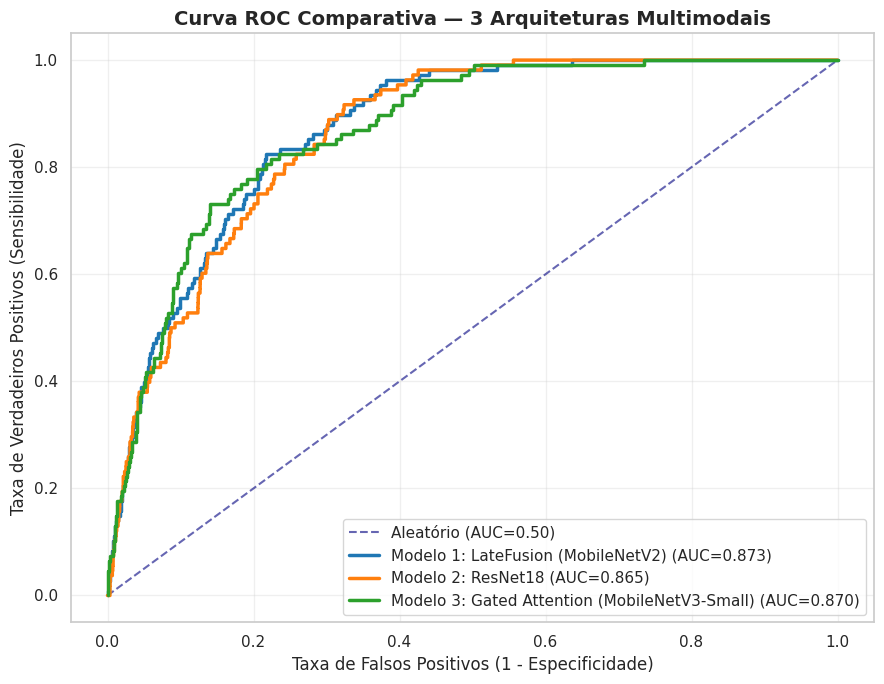

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CURVAS ROC COMPARATIVAS
# AUC-ROC: área sob a curva — 1.0=perfeito, 0.5=aleatório
# ─────────────────────────────────────────────────────────────────────────────
probabilidades = [probs1, probs2, probs3]
cores = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(9, 7))
plt.plot([0,1],[0,1], '--', color='navy', lw=1.5, alpha=0.6, label='Aleatório (AUC=0.50)')

for i, prob in enumerate(probabilidades):
    fpr, tpr, _ = roc_curve(y_true, prob)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=cores[i], lw=2.5, label=f'{titulos[i]} (AUC={auc_val:.3f})')

plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
plt.title('Curva ROC Comparativa — 3 Arquiteturas Multimodais',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

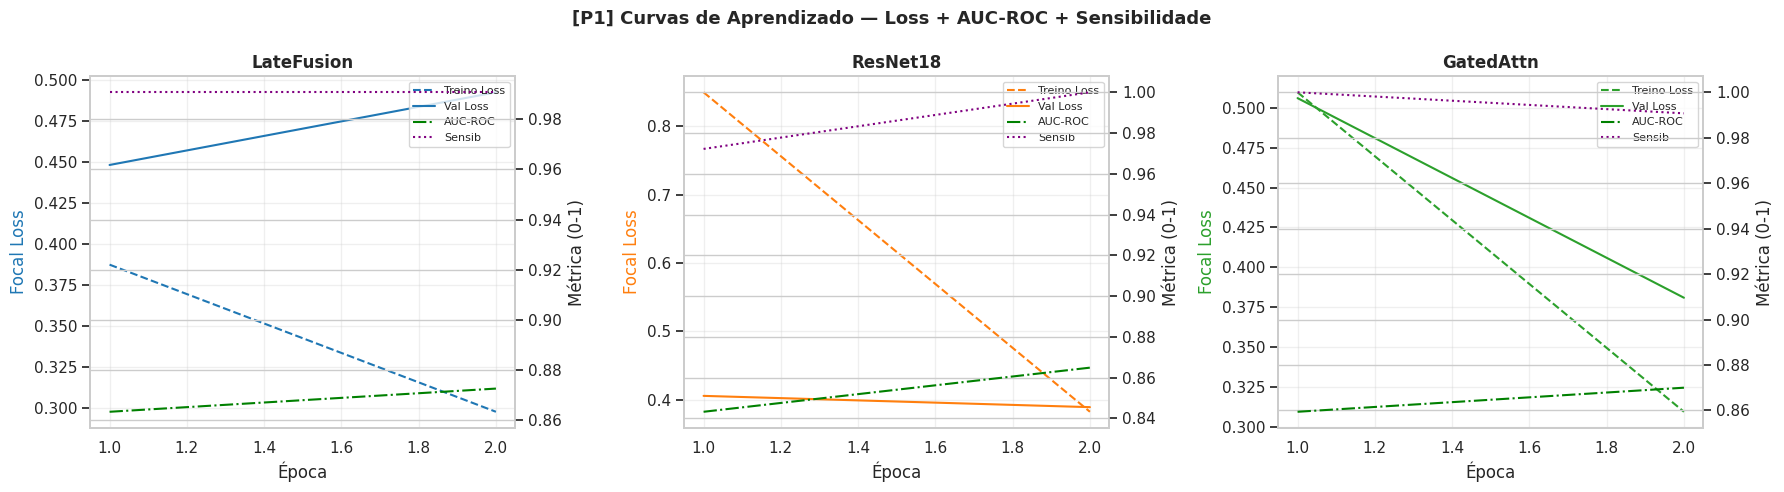

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CURVAS DE APRENDIZADO
# [P1] AUC-ROC e Sensibilidade — sem acurácia simples
# ─────────────────────────────────────────────────────────────────────────────
hists   = [hist1, hist2, hist3]
nomes_h = ['LateFusion', 'ResNet18', 'GatedAttn']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nome, hist, cor) in enumerate(zip(nomes_h, hists, cores)):
    ax = axes[i]
    eps = range(1, len(hist['train_loss'])+1)
    ax.plot(eps, hist['train_loss'], '--', color=cor, label='Treino Loss')
    ax.plot(eps, hist['val_loss'],   '-',  color=cor, label='Val Loss')
    ax2 = ax.twinx()
    ax2.plot(eps, hist['val_auc'],    '-.',  color='green',  label='AUC-ROC')
    ax2.plot(eps, hist['val_recall'], ':',   color='purple', label='Sensib')
    ax.set_title(nome, fontsize=12, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Focal Loss', color=cor)
    ax2.set_ylabel('Métrica (0-1)')
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle('[P1] Curvas de Aprendizado — Loss + AUC-ROC + Sensibilidade',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TABELA FINAL DE MÉTRICAS
# [P1] Acurácia incluída apenas para demonstrar que é enganosa:
# todos terão ~98% mesmo com Sensibilidade baixa.
# ─────────────────────────────────────────────────────────────────────────────
def calcular_especificidade(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp + 1e-9)

resultados = []
for titulo, prob, pred in zip(titulos, probabilidades, predicoes):
    fpr, tpr, _ = roc_curve(y_true, prob)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    resultados.append({
        'Arquitetura':              titulo,
        'Sensibilidade ↑':         round(recall_score(y_true, pred, zero_division=0), 4),
        'AUC-ROC ↑':               round(auc(fpr, tpr), 4),
        'F1-Score ↑':              round(f1_score(y_true, pred, zero_division=0), 4),
        'Especificidade ↑':        round(calcular_especificidade(y_true, pred), 4),
        'TP (Malignos detect.)':   int(tp),
        'FN (Malignos perdidos)':  int(fn),
        'Acurácia (enganosa)':     round((tp+tn)/(tp+tn+fp+fn+1e-9), 4),
    })

df_resultados = pd.DataFrame(resultados).set_index('Arquitetura')

# Destaca em verde o melhor valor em cada coluna (exceto FN e Acurácia)
cols_max = ['Sensibilidade ↑','AUC-ROC ↑','F1-Score ↑','Especificidade ↑','TP (Malignos detect.)']
cols_min = ['FN (Malignos perdidos)']

display(
    df_resultados.style
    .highlight_max(subset=cols_max, color='lightgreen', axis=0)
    .highlight_min(subset=cols_min, color='lightgreen', axis=0)
    .set_caption('[P1] Verde = melhor. Sensibilidade é a métrica mais crítica.')
    .format(precision=4)
)

print('\n[P1] Resumo das soluções para as peculiaridades do ISIC 2020:')
print('  P1: Desbalanceamento 55:1  → Focal Loss + WeightedRandomSampler')
print('  P2: Leakage por paciente   → GroupKFold (sanity check: 0 vazamentos)')
print('  P3: 82% diagnosis unknown  → Apenas age, sex, anatomy como features')
print('  P4: NaN + age==0 anômalo   → 0→NaN, mediana, StandardScaler, One-Hot')
print('  P5: Imagens dermoscópicas  → 7 etapas de augmentação específica')

,Sensibilidade ↑,AUC-ROC ↑,F1-Score ↑,Especificidade ↑,TP (Malignos detect.),FN (Malignos perdidos),Acurácia (enganosa)
Arquitetura,,,,,,,
Modelo 1: LateFusion (MobileNetV2),0.9907,0.8726,0.0542,0.4269,107,1,0.4361
Modelo 2: ResNet18,1.0000,0.8649,0.0496,0.3652,108,0,0.3755
Modelo 3: Gated Attention (MobileNetV3-Small),0.9907,0.8700,0.0544,0.4293,107,1,0.4385



[P1] Resumo das soluções para as peculiaridades do ISIC 2020:
  P1: Desbalanceamento 55:1  → Focal Loss + WeightedRandomSampler
  P2: Leakage por paciente   → GroupKFold (sanity check: 0 vazamentos)
  P3: 82% diagnosis unknown  → Apenas age, sex, anatomy como features
  P4: NaN + age==0 anômalo   → 0→NaN, mediana, StandardScaler, One-Hot
  P5: Imagens dermoscópicas  → 7 etapas de augmentação específica
